# Gestalt Principles in Data Visualization
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)
#### PPT5 Demo — Proximity, Similarity, Connectedness, Continuity, Symmetry, Closure, Common Region, Figure & Ground, Common Fate

**Dataset:** Netflix Titles (`netflix_titles.csv`) — 7,787 Movies and TV Shows with
genre, country, rating, and release/added dates (TidyTuesday / Netflix catalog, up to 2021).

**The scenario:** You are a junior data analyst at **StreamScope Analytics**, reviewing
the content-strategy dashboard before it goes to the content acquisition team. Gestalt
psychology explains how the brain automatically groups isolated elements into organized
wholes — every principle below is a lever you can pull (or accidentally fight against)
in a chart's layout.

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("ppt5_netflix_titles.csv")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Rows: 8,807  |  Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


## 1. Proximity

**Principle:** Objects positioned close together are perceived as belonging to the same
group. Below, the *same* rating counts are shown two ways: cramped with equal spacing
everywhere (no grouping cue), versus with **extra whitespace** separating Movie ratings
from TV ratings — the grouping becomes obvious without adding a single label.

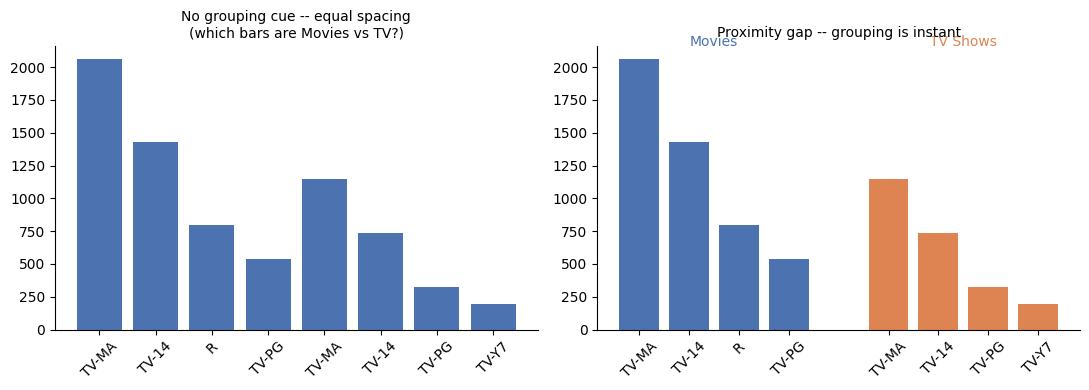

In [4]:
movie_ratings = df[df["type"] == "Movie"]["rating"].value_counts().head(4)
tv_ratings = df[df["type"] == "TV Show"]["rating"].value_counts().head(4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# BAD: equal spacing everywhere -- no visual grouping cue
all_labels = list(movie_ratings.index) + list(tv_ratings.index)
all_values = list(movie_ratings.values) + list(tv_ratings.values)
axes[0].bar(range(len(all_labels)), all_values, color="#4C72B0")
axes[0].set_xticks(range(len(all_labels)))
axes[0].set_xticklabels(all_labels, rotation=45)
axes[0].set_title("No grouping cue -- equal spacing\n(which bars are Movies vs TV?)", fontsize=10)

# GOOD: a gap between the two groups signals "these belong together"
positions = list(range(len(movie_ratings))) + list(range(len(movie_ratings) + 1,
                                                           len(movie_ratings) + 1 + len(tv_ratings)))
colors = ["#4C72B0"] * len(movie_ratings) + ["#DD8452"] * len(tv_ratings)
axes[1].bar(positions, all_values, color=colors)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(all_labels, rotation=45)
axes[1].text(1.5, max(all_values) * 1.05, "Movies", ha="center", fontsize=10, color="#4C72B0")
axes[1].text(6.5, max(all_values) * 1.05, "TV Shows", ha="center", fontsize=10, color="#DD8452")
axes[1].set_title("Proximity gap -- grouping is instant", fontsize=10)

plt.tight_layout()
plt.show()

## 2. Similarity

**Principle:** Objects with similar color, shape, size or texture are perceived as
belonging together — like a subway map using one color per line. Below, a chart uses
**one consistent color per `type`** across every bar, so the eye groups "all Movies" and
"all TV Shows" instantly, even though they're not adjacent.

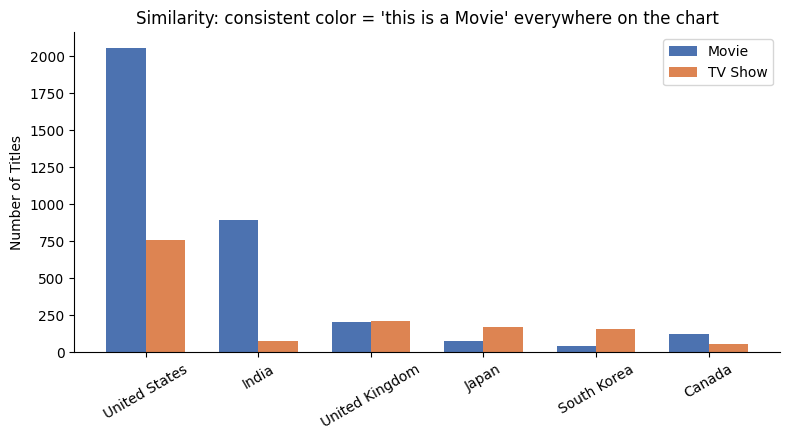

In [5]:
top_countries = df["country"].value_counts().head(6).index
sub = df[df["country"].isin(top_countries)]
grouped = sub.groupby(["country", "type"]).size().unstack(fill_value=0).loc[top_countries]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(grouped))
width = 0.35
ax.bar(x - width/2, grouped["Movie"], width, label="Movie", color="#4C72B0")
ax.bar(x + width/2, grouped["TV Show"], width, label="TV Show", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=30)
ax.set_ylabel("Number of Titles")
ax.set_title("Similarity: consistent color = 'this is a Movie' everywhere on the chart")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Connectedness

**Principle:** Objects joined by a line or edge are perceived as related — even more
strongly than proximity or color. Below, a **slope chart** connects each country's 2019
title count to its 2020 count with a literal line, making the year-over-year change the
star of the chart rather than two disconnected bar groups.

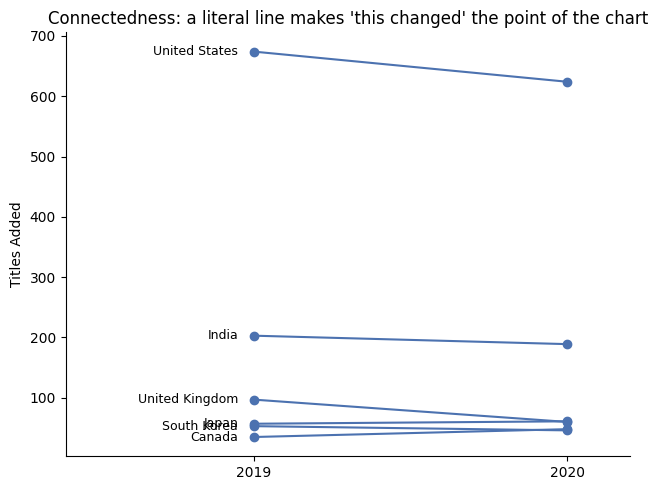

In [6]:
yearly = df[df["year_added"].isin([2019, 2020])]
counts = yearly[yearly["country"].isin(top_countries)].groupby(["country", "year_added"]).size().unstack(fill_value=0)
counts = counts.loc[top_countries]

fig, ax = plt.subplots(figsize=(6.5, 5))
for country in counts.index:
    y2019, y2020 = counts.loc[country, 2019], counts.loc[country, 2020]
    ax.plot([0, 1], [y2019, y2020], marker="o", color="#4C72B0")
    ax.text(-0.05, y2019, country, ha="right", va="center", fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(["2019", "2020"])
ax.set_xlim(-0.6, 1.2)
ax.set_ylabel("Titles Added")
ax.set_title("Connectedness: a literal line makes 'this changed' the point of the chart")
plt.tight_layout()
plt.show()

## 4. Continuity  

**Principle:** The eye naturally follows smooth, continuous paths rather than abrupt
changes. Below, titles-added-per-year is plotted first as a **jumbled, unsorted** line
(the eye has to jump back and forth) and then as a **smooth, chronologically sorted**
line the eye can trace effortlessly.

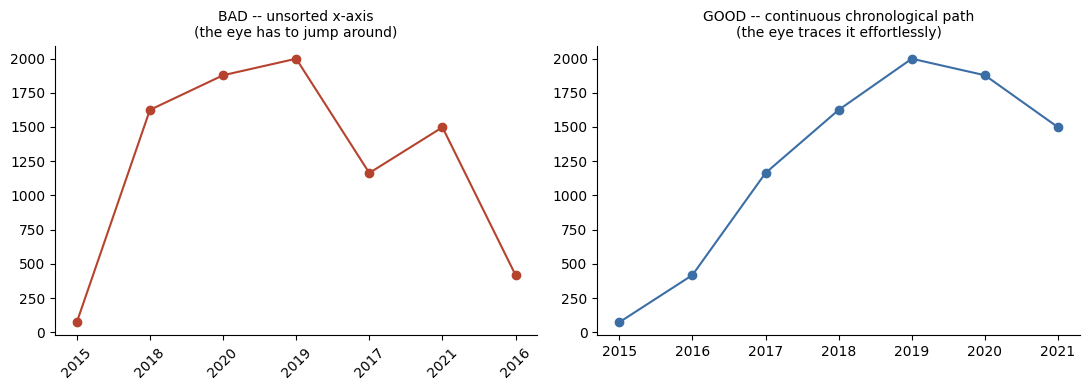

In [7]:
by_year = df["year_added"].value_counts()
by_year = by_year[by_year.index >= 2015]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# BAD: points plotted in an arbitrary (unsorted) order -- breaks continuity
shuffled = by_year.sample(frac=1, random_state=1)
axes[0].plot(range(len(shuffled)), shuffled.values, marker="o", color="#b5432e")
axes[0].set_xticks(range(len(shuffled)))
axes[0].set_xticklabels(shuffled.index.astype(int), rotation=45)
axes[0].set_title("BAD -- unsorted x-axis\n(the eye has to jump around)", fontsize=10)

# GOOD: sorted chronologically -- a single smooth path
ordered = by_year.sort_index()
axes[1].plot(ordered.index, ordered.values, marker="o", color="#3b6ea5")
axes[1].set_title("GOOD -- continuous chronological path\n(the eye traces it effortlessly)", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Symmetry  

**Principle:** Symmetrical layouts are perceived as complete and belonging together,
which improves comparison. Below is a **back-to-back (mirrored) bar chart** — a classic
symmetry-driven layout for comparing two distributions, here Movies vs. TV Shows across
the same rating categories.

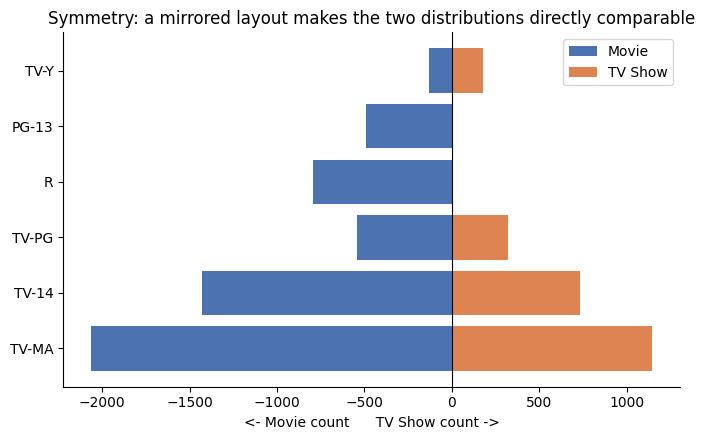

In [8]:
ratings = ["TV-MA", "TV-14", "TV-PG", "R", "PG-13", "TV-Y"]
movie_counts = df[df["type"] == "Movie"]["rating"].value_counts().reindex(ratings, fill_value=0)
tv_counts = df[df["type"] == "TV Show"]["rating"].value_counts().reindex(ratings, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
y = np.arange(len(ratings))
ax.barh(y, -movie_counts.values, color="#4C72B0", label="Movie")
ax.barh(y, tv_counts.values, color="#DD8452", label="TV Show")
ax.set_yticks(y)
ax.set_yticklabels(ratings)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("<- Movie count      TV Show count ->")
ax.set_title("Symmetry: a mirrored layout makes the two distributions directly comparable")
ax.legend()
plt.tight_layout()
plt.show()

TV-14 is a rating from the TV Parental Guidelines system, meaning "Parents Strongly Cautioned — content may be unsuitable for children under 14
Blue bar (left side): Extends to around –1500 to –1600, meaning roughly 1500+ Movies on Netflix are rated TV-14.
Orange bar (right side): Extends to around +1000, meaning roughly 1000 TV Shows are rated TV-14
Grouped bars would've been acceptable and told the same story. Mirrored bars are a slightly more polished choice specifically because you're comparing two categories (Movie vs TV Show) against a shared categorical axis (rating) — it's optimized for exactly that pattern.
EXAMPLE:
his is actually the original, most famous use case for this exact chart type — it's literally called a "population pyramid" in demographics.

Setup:

Y-axis: Age groups (0–4, 5–9, 10–14, ... 80+)
Left side (mirrored/negative): Male population count
Right side: Female population count
Center line: zero
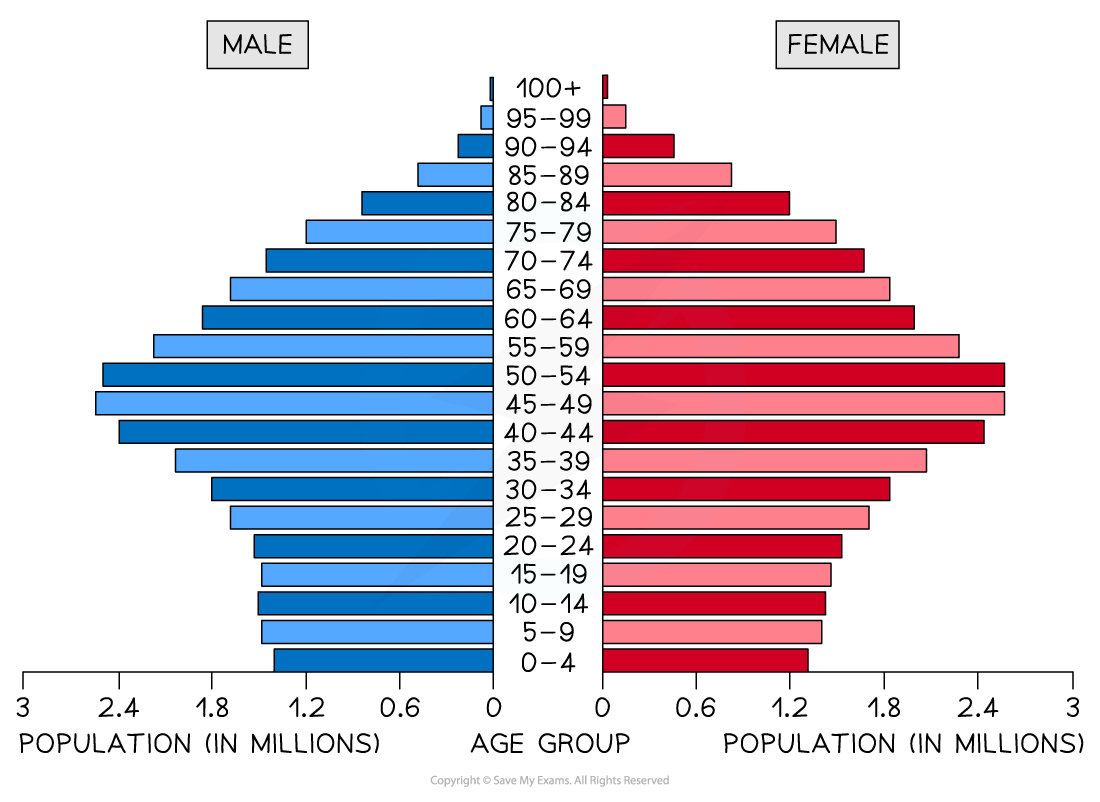


## 6. Closure
**Principle:** The brain fills in missing information to perceive a complete object —
a broken or dashed circle is still read as "a circle." Below, a donut chart is drawn with
visible **gaps between segments**; the eye still perceives one complete ring, not five
disconnected arcs.

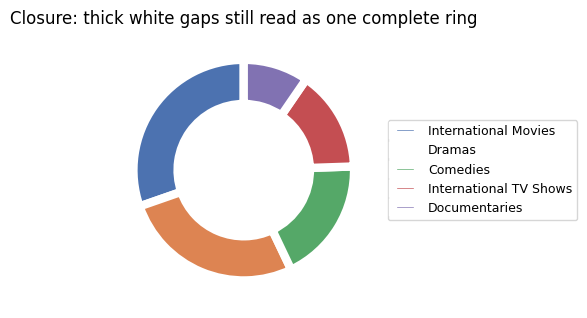

In [9]:
top_genres = df["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, ax = plt.subplots(figsize=(5, 5))
wedges, _ = ax.pie(top_genres.values, colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"],
                    startangle=90, wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 6})
ax.legend(wedges, top_genres.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title("Closure: thick white gaps still read as one complete ring")
plt.tight_layout()
plt.show()

## 7. Common Region

**Principle:** Objects enclosed within the same boundary are perceived as belonging
together — dashboard cards, panels, and grouped legends all rely on this. Below, three
summary metrics are grouped visually with a subtle enclosing box per card — no extra
labels are needed to show they belong to the same "content mix" panel.

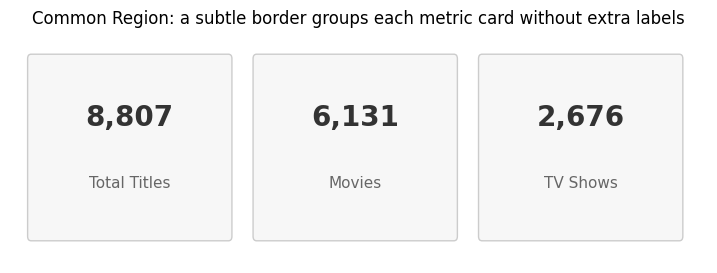

In [10]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")

metrics = [
    ("Total Titles", f"{len(df):,}"),
    ("Movies", f"{(df['type']=='Movie').sum():,}"),
    ("TV Shows", f"{(df['type']=='TV Show').sum():,}"),
]

for i, (label, value) in enumerate(metrics):
    x0 = i * 3.2
    ax.add_patch(patches.FancyBboxPatch((x0, 0), 2.8, 2, boxstyle="round,pad=0.05",
                                          linewidth=1, edgecolor="#cccccc", facecolor="#f7f7f7"))
    ax.text(x0 + 1.4, 1.25, value, ha="center", fontsize=20, fontweight="bold", color="#333333")
    ax.text(x0 + 1.4, 0.55, label, ha="center", fontsize=11, color="#666666")

ax.set_xlim(-0.3, 3 * 3.2)
ax.set_ylim(-0.3, 2.3)
ax.set_title("Common Region: a subtle border groups each metric card without extra labels")
plt.show()

## 8. Figure & Ground

**Principle:** The visual system separates a scene into a **figure** (object of focus)
and a **ground** (background). Good visualizations use strong contrast and muted
backgrounds so the figure is unambiguous. Below, the same chart is shown with a
low-contrast figure/ground relationship and a fixed, high-contrast version.

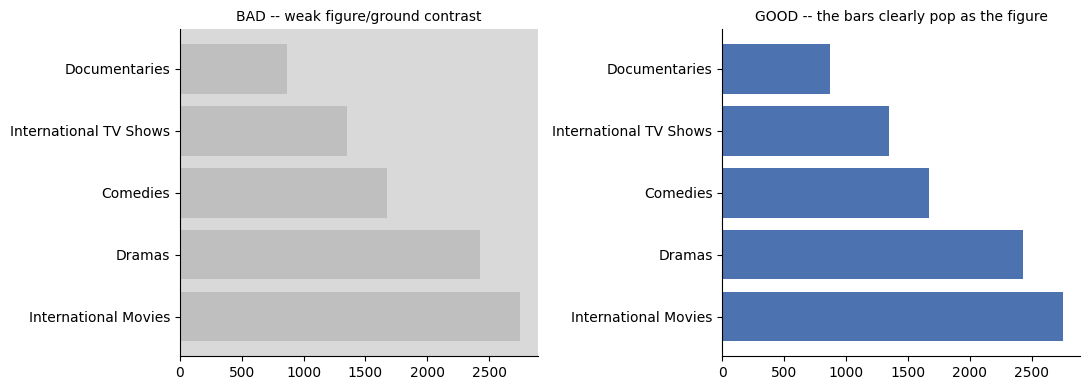

In [11]:
top5 = df["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# BAD: low contrast between bars and background -- figure barely separates from ground
axes[0].set_facecolor("#d9d9d9")
axes[0].barh(top5.index, top5.values, color="#bfbfbf")
axes[0].set_title("BAD -- weak figure/ground contrast", fontsize=10)

# GOOD: muted background, high-contrast figure
axes[1].set_facecolor("white")
axes[1].barh(top5.index, top5.values, color="#4C72B0")
axes[1].set_title("GOOD -- the bars clearly pop as the figure", fontsize=10)

plt.tight_layout()
plt.show()

## 9. Common Fate  
**Principle:** Objects moving in the same direction or changing together are perceived
as belonging to one group — a flock of birds reads as one group because they move
together. In a static notebook we simulate this with **small multiples**: every
country's trend line is drawn the same faint gray *except* the one moving in the same
direction as the overall catalog — it's highlighted, visually "grouped" with the trend.

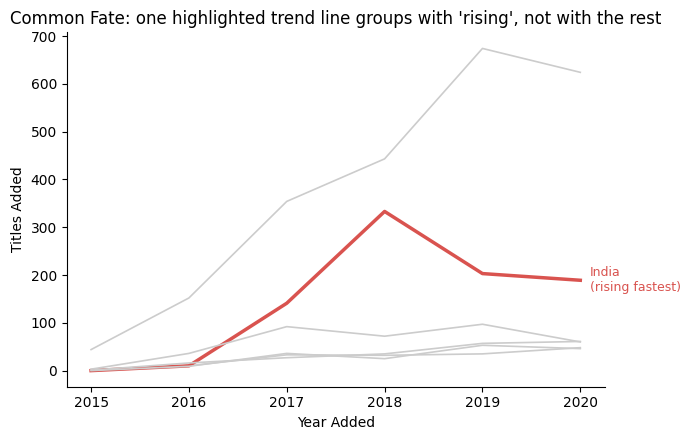

In [12]:
by_year_country = df[df["country"].isin(top_countries)].groupby(["year_added", "country"]).size().unstack(fill_value=0)
by_year_country = by_year_country.loc[(by_year_country.index >= 2015) & (by_year_country.index <= 2020)]

fig, ax = plt.subplots(figsize=(7, 4.5))
for country in by_year_country.columns:
    is_rising = by_year_country[country].iloc[-1] > by_year_country[country].iloc[0]
    color = "#D9534F" if is_rising and country == "India" else "#cccccc"
    lw = 2.5 if color == "#D9534F" else 1.2
    ax.plot(by_year_country.index, by_year_country[country], color=color, lw=lw)

ax.text(2020.1, by_year_country["India"].iloc[-1], "India\n(rising fastest)",
        color="#D9534F", fontsize=9, va="center")
ax.set_xlabel("Year Added")
ax.set_ylabel("Titles Added")
ax.set_title("Common Fate: one highlighted trend line groups with 'rising', not with the rest")
plt.tight_layout()
plt.show()

## 10. Applying Gestalt Principles to Data Visualization  *(Slide 14)*

| Principle | Design Guideline |
|---|---|
| Proximity | Group related information with spacing |
| Similarity | Use consistent colors and shapes |
| Connectedness | Connect related data with lines |
| Continuity | Preserve smooth visual flow |
| Symmetry | Use balanced layouts for comparison |
| Closure | Simplify incomplete shapes |
| Common Region | Enclose related elements |
| Figure & Ground | Maximize contrast |
| Common Fate | Animate related elements together |

## Key Takeaways

1. The brain **automatically groups** isolated elements — a well-designed chart works
   with this tendency instead of fighting it.
2. **Spacing, color, connecting lines, and enclosing boxes** are all free grouping
   signals that need no extra labels or legends.
3. **Symmetry and continuity** reduce the mental work needed to compare or trace data.
4. **Figure/ground contrast** and **common fate** highlighting direct attention to what
   matters most in a chart.

> *Good visualizations let the brain's own organizing instincts do the work.*